# 01 — Data Cleaning

Pipeline:
1. Load raw `results_linux.csv`
2. Detect & remove outliers (IQR × 1.5, per language × benchmark group)
3. Convert units to human-readable values
4. Aggregate to mean per (language, benchmark)
5. Export `results_clean.csv`

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

RAW_CSV  = Path('../results/results_linux.csv')
OUT_CSV  = Path('../results/results_clean.csv')
FIGS_DIR = Path('../results/figs')
FIGS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load raw data

In [19]:
df = pd.read_csv(RAW_CSV)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (1440, 16)


,run_id,measured_at,language,benchmark,cpu_carbon_rapl_msr_component-package_0-ug,cpu_energy_rapl_msr_component-package_0-uj,disk_total_read_cgroup_container-container-bytes,disk_total_write_cgroup_container-container-bytes,embodied_carbon_share_machine-system-ug,memory_carbon_rapl_msr_component-dram_0-ug,memory_energy_rapl_msr_component-dram_0-uj,network_carbon_formula_global-formula-ug,network_energy_formula_global-formula-uj,network_power_formula_global-formula-mw,network_total_cgroup_container-container-bytes,phase_time_syscall_system-system-us
0,e6566d0c-a6fb-4948-98e6-9a9ff385fa06,2026-05-13 11:10:23,c,mandelbrot,3209,34593257,221184,0,1799,57,617790,0,0,0,0,1253874
1,1990c743-56d1-436c-b180-6f421ee64ef0,2026-05-13 11:07:10,c,fasta,3666,39518486,0,0,2085,83,894832,0,0,0,0,1452964
2,8fdb9432-4675-4626-b9cd-1e8e3b128b5f,2026-05-13 11:04:08,c,spectral-norm,897,9665342,221184,0,581,14,155394,0,0,0,0,405037


## 2. Outlier detection & removal (IQR per group)

In [20]:
# Numeric metric columns only (exclude identifiers)
ID_COLS     = ['run_id', 'measured_at', 'language', 'benchmark']
METRIC_COLS = [c for c in df.columns if c not in ID_COLS]

def iqr_mask(group: pd.DataFrame, cols: list[str], factor: float = 1.5) -> pd.Series:
    """Return a boolean mask — True means the row is an outlier on ≥1 metric."""
    outlier = pd.Series(False, index=group.index)
    for col in cols:
        q1, q3 = group[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        if iqr == 0:          # constant column in this group — skip
            continue
        lo, hi = q1 - factor * iqr, q3 + factor * iqr
        outlier |= (group[col] < lo) | (group[col] > hi)
    return outlier

outlier_flags = (
    df.groupby(['language', 'benchmark'], group_keys=False)
      .apply(lambda g: iqr_mask(g, METRIC_COLS))
)

n_outliers = outlier_flags.sum()
print(f'Outlier runs flagged : {n_outliers} / {len(df)}  ({n_outliers/len(df)*100:.1f}%)')

df_clean = df[~outlier_flags].copy()
print(f'Rows after removal   : {len(df_clean)}')

Outlier runs flagged : 252 / 1440  (17.5%)
Rows after removal   : 1188


/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_9546/1854473554.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_clean = df[~outlier_flags].copy()


In [21]:
# Per-group count after cleaning — flag any group with fewer than 5 clean runs
counts = df_clean.groupby(['language', 'benchmark']).size().rename('n_runs')
low = counts[counts < 5]
if len(low):
    print('⚠ Groups with < 5 clean runs:')
    print(low.to_string())
else:
    print('All groups have ≥ 5 clean runs.')
counts.unstack('benchmark').fillna(0).astype(int)

All groups have ≥ 5 clean runs.


benchmark,binary-trees,fannkuch-redux,fasta,k-nucleotide,mandelbrot,n-body,regex-redux,spectral-norm
language,,,,,,,,
c,7,9,7,10,6,10,9,7
cpp,9,6,10,7,10,6,7,8
csharp,9,10,7,9,7,8,8,8
dart,7,6,6,9,10,8,9,6
erlang,9,10,7,8,7,8,8,10
fsharp,10,10,8,10,8,10,9,8
go,8,8,10,8,8,8,10,8
haskell,9,10,7,7,7,9,9,10
java,8,7,8,9,7,9,10,8


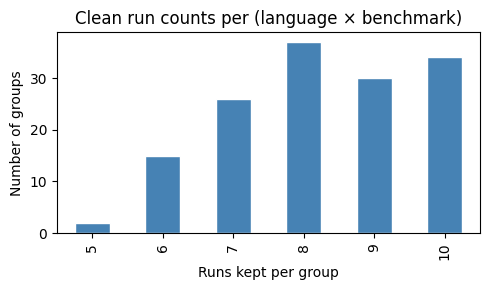

In [22]:
# Visual: distribution of clean run counts per group
fig, ax = plt.subplots(figsize=(5, 3))
counts.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Runs kept per group')
ax.set_ylabel('Number of groups')
ax.set_title('Clean run counts per (language × benchmark)')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'outlier_counts.pdf', bbox_inches='tight')
plt.show()

## 3. Unit conversions

In [23]:
# Conversion rules keyed by column-name suffix.
# Each entry: (divisor, new_unit_label)
CONVERSIONS = {
    '-ug' : (1e6,    'g'),        # micro-grams  → grams
    '-uj' : (1e6,    'J'),        # micro-Joules → Joules
    '-mw' : (1e3,    'W'),        # milli-Watts  → Watts
    '-us' : (1e6,    's'),        # micro-seconds → seconds
    '-bytes': (1e6,  'MB'),       # bytes → MB  (disk/net totals)
}

rename_map = {}
for col in METRIC_COLS:
    for suffix, (divisor, unit) in CONVERSIONS.items():
        if col.endswith(suffix):
            base = col[: -len(suffix)]
            new_col = f'{base}-{unit.lower()}'
            df_clean[new_col] = df_clean[col] / divisor
            rename_map[col] = new_col
            break

# Drop the original raw-unit columns
df_clean = df_clean.drop(columns=list(rename_map.keys()))

METRIC_COLS_CONV = [c for c in df_clean.columns if c not in ID_COLS]
print('Converted columns:')
for old, new in rename_map.items():
    print(f'  {old}  →  {new}')

Converted columns:
  cpu_carbon_rapl_msr_component-package_0-ug  →  cpu_carbon_rapl_msr_component-package_0-g
  cpu_energy_rapl_msr_component-package_0-uj  →  cpu_energy_rapl_msr_component-package_0-j
  disk_total_read_cgroup_container-container-bytes  →  disk_total_read_cgroup_container-container-mb
  disk_total_write_cgroup_container-container-bytes  →  disk_total_write_cgroup_container-container-mb
  embodied_carbon_share_machine-system-ug  →  embodied_carbon_share_machine-system-g
  memory_carbon_rapl_msr_component-dram_0-ug  →  memory_carbon_rapl_msr_component-dram_0-g
  memory_energy_rapl_msr_component-dram_0-uj  →  memory_energy_rapl_msr_component-dram_0-j
  network_carbon_formula_global-formula-ug  →  network_carbon_formula_global-formula-g
  network_energy_formula_global-formula-uj  →  network_energy_formula_global-formula-j
  network_power_formula_global-formula-mw  →  network_power_formula_global-formula-w
  network_total_cgroup_container-container-bytes  →  network_total_cg

## 4. Aggregate to mean per (language, benchmark)

In [24]:
df_mean = (
    df_clean
      .groupby(['language', 'benchmark'])[METRIC_COLS_CONV]
      .mean()
      .reset_index()
)
print(f'Aggregated shape: {df_mean.shape}')
df_mean.head()

Aggregated shape: (144, 14)


,language,benchmark,cpu_carbon_rapl_msr_component-package_0-g,cpu_energy_rapl_msr_component-package_0-j,disk_total_read_cgroup_container-container-mb,disk_total_write_cgroup_container-container-mb,embodied_carbon_share_machine-system-g,memory_carbon_rapl_msr_component-dram_0-g,memory_energy_rapl_msr_component-dram_0-j,network_carbon_formula_global-formula-g,network_energy_formula_global-formula-j,network_power_formula_global-formula-w,network_total_cgroup_container-container-mb,phase_time_syscall_system-system-s
0,c,binary-trees,0.018134,195.452598,0.221184,0.0,0.009182,0.000660,7.112526,4.285714e-07,0.004434,0.0,0.000030,6.398797
1,c,fannkuch-redux,0.018467,199.042885,0.221184,0.0,0.008273,0.000159,1.716583,3.777778e-06,0.040568,0.0,0.000274,5.765902
2,c,fasta,0.003627,39.090499,0.000000,0.0,0.002090,0.000083,0.895423,0.000000e+00,0.000000,0.0,0.000000,1.456821
3,c,k-nucleotide,0.000872,9.397647,25.640960,0.0,0.000813,0.000025,0.270444,1.000000e-07,0.001035,0.0,0.000007,0.566645
4,c,mandelbrot,0.003246,34.987582,0.221184,0.0,0.001803,0.000055,0.594882,0.000000e+00,0.000000,0.0,0.000000,1.256330


## 5. Export

In [25]:
df_mean.to_csv(OUT_CSV, index=False)
print(f'Saved → {OUT_CSV}')

# Also save the per-run cleaned frame (before aggregation) for reference
df_clean.to_csv(OUT_CSV.with_name('results_clean_runs.csv'), index=False)
print(f'Saved → {OUT_CSV.with_name("results_clean_runs.csv")}')

Saved → ../results/results_clean.csv
Saved → ../results/results_clean_runs.csv
